In [233]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt


def distribution_func(size_min, size_max, portal):
    l1, l2 = portal
    x11, y11, x12, y12 = l1
    x21, y21, x22, y22 = l2
    length1 = np.sqrt((x12 - x11) ** 2 + (y12 - y11) ** 2)
    length2 = np.sqrt((x22 - x21) ** 2 + (y22 - y21) ** 2)
    dx1, dy1 = [(x12 - x11) / length1, (y12 - y11) / length1]
    dx2, dy2 = [(x22 - x21) / length2, (y22 - y21) / length2]

    half_distance = (length1 + length2) / 4

    def _base_distribution_func(x):
        return (np.exp(x) - 1) / (np.exp(1) - 1)

    def _total_segment_length(size_min, size_max, num_segs):
        d = 0
        for i in range(num_segs):
            d += _base_distribution_func(i / num_segs) * size_max + size_min
        return d

    num_segs_min = int(half_distance / size_max) - 1
    num_segs_max = int(half_distance / size_min) + 1
    while True:
        num_segs = (num_segs_min + num_segs_max) // 2
        d = _total_segment_length(size_min, size_max, num_segs)
        if _total_segment_length(size_min, size_max, num_segs - 1) <= half_distance <= d:
            num_segs -= 1
            break
        elif _total_segment_length(size_min, size_max, num_segs + 1) >= half_distance >= d:
            break
        elif d > half_distance:
            num_segs_max = num_segs
        else:
            num_segs_min = num_segs
    interp_nodes = [0.0] * (2 * num_segs + 1)
    for i in range(num_segs - 1):
        interp_nodes[i + 1] = interp_nodes[i] + _base_distribution_func(i / num_segs) * size_max + size_min
    interp_nodes[num_segs] = half_distance
    for i in range(num_segs + 1, 2 * num_segs + 1):
        interp_nodes[i] = 2 * half_distance - interp_nodes[2 * num_segs - i]

    p1 = [(0, 0)] * len(interp_nodes)
    p2 = [(0, 0)] * len(interp_nodes)
    for i, d in enumerate(interp_nodes):
        d /= half_distance * 2
        d1 = d * length1
        d2 = d * length2
        p1[i] = (x11 + dx1 * d1, y11 + dy1 * d1)
        p2[i] = (x21 + dx2 * d2, y21 + dy2 * d2)
        
    return p1, p2

In [234]:
def generate_domain_mesh(portals, domain_side_length=10, mesh_size_regular=0.1, mesh_size_min=0.01):
    
    if mesh_size_regular < mesh_size_min:
        raise ValueError("网格尺寸不合理")

    def add_points_to_mesh(domain, points):
        n = len(points)
        point_tags = [0] * n
        line_tags = [0] * (n - 1)
        for i, (x, y) in enumerate(points):
            point_tags[i] = gmsh.model.occ.addPoint(x, y, 0, mesh_size_regular)
        for i in range(n - 1):
            line_tags[i] = gmsh.model.occ.addLine(point_tags[i], point_tags[i + 1])
        gmsh.model.occ.synchronize()
        for i in range(n - 1):
            gmsh.model.occ.fragment([(2, domain)], [(1, line_tags[i])])
        return point_tags
        
        
    def add_portal_to_mesh(domain, portal):
        p1, p2 = distribution_func(mesh_size_min, mesh_size_regular, portal)
        p1_tags = add_points_to_mesh(domain, p1)
        p2_tags = add_points_to_mesh(domain, p2)
        return p1_tags, p2_tags
    
    D = domain_side_length
    gmsh.initialize()
    gmsh.model.add("domain_mesh")
    domain = gmsh.model.occ.addRectangle(-D, -D, 0, 2 * D, 2 * D)
    portal_tags = []
    for portal in portals:
        portal_tags.append(add_portal_to_mesh(domain, portal))

    gmsh.model.occ.synchronize()
    gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size_regular)
    gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size_min)
    gmsh.model.mesh.generate(2)

    node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
    Nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

    _, elem_tags, node_tags = gmsh.model.mesh.getElements(2, domain)
    tri_node_tags = node_tags[0]
    Elements = np.array(tri_node_tags, dtype=int).reshape(-1, 3) - 1

    gmsh.finalize()

    return Nodes, Elements

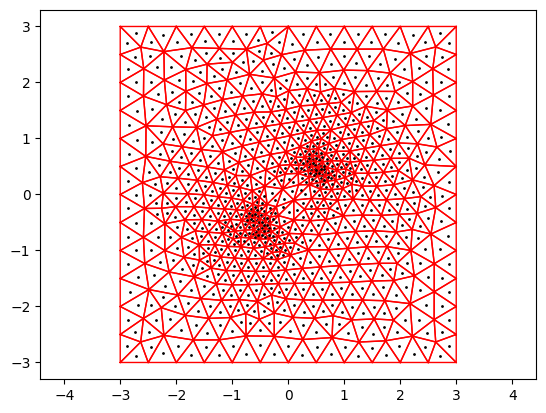

In [235]:
Nodes, Elements = generate_domain_mesh(
    [[(-0.4, -0.6, 0.6, 0.4), (-0.6, -0.4, 0.4, 0.6)]], domain_side_length=3, mesh_size_regular=0.5, mesh_size_min=0.1
)


def plot_mesh(Nodes, Elements):
    for i, (a, b, c) in enumerate(Elements):
        x1, y1 = Nodes[a]
        x2, y2 = Nodes[b]
        x3, y3 = Nodes[c]
        x = (x1 + x2 + x3) / 3
        y = (y1 + y2 + y3) / 3
        plt.plot([x1, x2, x3, x1], [y1, y2, y3, y1], color="r", linewidth=1)
        plt.plot(x, y, "ko", markersize=1)
    

    plt.axis("equal")
    plt.savefig("a.svg")
    plt.show()


plot_mesh(Nodes, Elements)